In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [6]:
dataset = pd.read_csv("C:/Users/user/OneDrive/Documents/Learn AI/ML_Projects/car-price-prediction/dataset/car_sales_data.csv")

In [41]:
dataset.shape

(50000, 12)

In [7]:
dataset.head(10)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


In [8]:
dataset = dataset.drop('Model',axis = 1)

In [9]:
dataset.rename(columns={'Fuel type': 'Fuel_type'}, inplace=True)

In [10]:
dataset.rename(columns={'Year of manufacture': 'Year_of_manufacture'}, inplace=True)

In [11]:
dataset.head()

,Manufacturer,Engine size,Fuel_type,Year_of_manufacture,Mileage,Price
0,Ford,1.0,Petrol,2002,127300,3074
1,Porsche,4.0,Petrol,2016,57850,49704
2,Ford,1.6,Diesel,2014,39190,24072
3,Toyota,1.8,Hybrid,1988,210814,1705
4,VW,1.0,Petrol,2006,127869,4101


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Engine size          50000 non-null  float64
 2   Fuel_type            50000 non-null  object 
 3   Year_of_manufacture  50000 non-null  int64  
 4   Mileage              50000 non-null  int64  
 5   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.3+ MB


In [13]:
dataset.isnull().sum()

Manufacturer           0
Engine size            0
Fuel_type              0
Year_of_manufacture    0
Mileage                0
Price                  0
dtype: int64

In [14]:
dataset.value_counts('Manufacturer')

Manufacturer
Ford       14959
VW         14913
Toyota     12554
BMW         4965
Porsche     2609
Name: count, dtype: int64

In [15]:
dataset.value_counts('Engine size')


Engine size
1.4    10060
2.0     7631
1.8     7032
1.0     6343
1.6     5509
1.2     4984
2.4     2364
2.2     1678
3.0     1368
4.0     1092
4.4      559
5.0      525
2.6      448
3.5      407
Name: count, dtype: int64

In [16]:
dataset.value_counts('Fuel_type')


Fuel_type
Petrol    25488
Diesel    13268
Hybrid    11244
Name: count, dtype: int64

Data Pre processing

In [17]:
dataset = pd.get_dummies(dataset, columns=["Manufacturer"])

In [18]:
dataset = pd.get_dummies(dataset, columns=['Fuel_type']).astype(int)

In [19]:
dataset.head()

,Engine size,Year_of_manufacture,Mileage,Price,Manufacturer_BMW,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Fuel_type_Diesel,Fuel_type_Hybrid,Fuel_type_Petrol
0,1,2002,127300,3074,0,1,0,0,0,0,0,1
1,4,2016,57850,49704,0,0,1,0,0,0,0,1
2,1,2014,39190,24072,0,1,0,0,0,1,0,0
3,1,1988,210814,1705,0,0,0,1,0,0,1,0
4,1,2006,127869,4101,0,0,0,0,1,0,0,1


In [20]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Engine size           50000 non-null  int64
 1   Year_of_manufacture   50000 non-null  int64
 2   Mileage               50000 non-null  int64
 3   Price                 50000 non-null  int64
 4   Manufacturer_BMW      50000 non-null  int64
 5   Manufacturer_Ford     50000 non-null  int64
 6   Manufacturer_Porsche  50000 non-null  int64
 7   Manufacturer_Toyota   50000 non-null  int64
 8   Manufacturer_VW       50000 non-null  int64
 9   Fuel_type_Diesel      50000 non-null  int64
 10  Fuel_type_Hybrid      50000 non-null  int64
 11  Fuel_type_Petrol      50000 non-null  int64
dtypes: int64(12)
memory usage: 4.6 MB


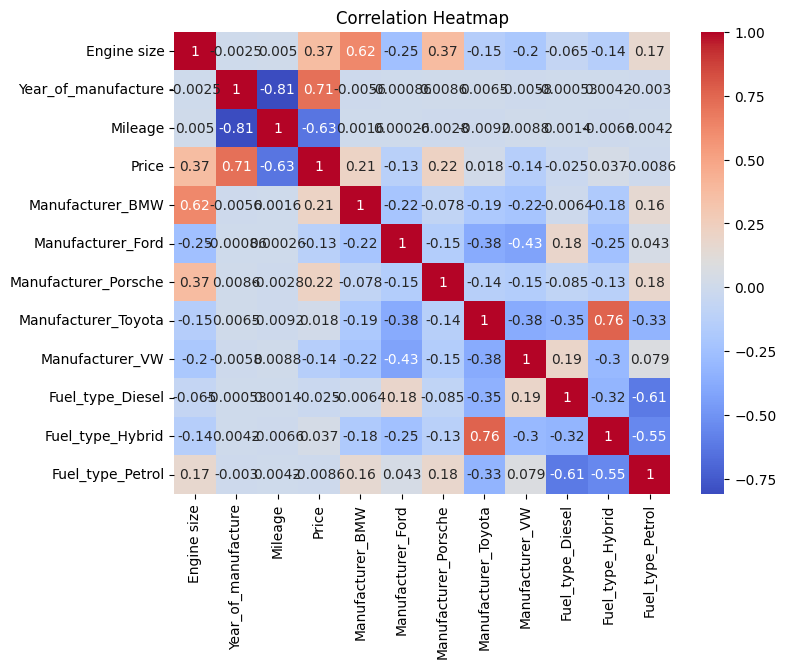

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = dataset.select_dtypes(include=['int64'])
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Idea: Use Year, Mileage, and Engine size as main features for price prediction. Manufacturer dummies add extra explanation.

Use Year, Mileage, Engine size + manufacturer dummies (especially Porsche/Toyota)

In [22]:
x = dataset.drop('Price',axis = 1)
y = dataset['Price']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
def model_evaluation(model):
    # Train the model
    model.fit(x_train, y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    r2 = r2_score(y_test, y_test_pred)

    # Print results
    print("Training MAE           :", train_mae)
    print("Test MAE               :", test_mae)
    print("Training RMSE          :", train_rmse)
    print("Test RMSE              :", test_rmse)
    print("R² Score (Test)        :", r2)

    # Cross-validation
    cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')
    print("Mean CV R² Score       :", cv_scores.mean())
    print("CV R² Scores           :", cv_scores)


In [25]:
model = LinearRegression()
model_evaluation(model)

Training MAE           : 6122.01421489296
Test MAE               : 6149.0700395271015
Training RMSE          : 9334.90967920091
Test RMSE              : 9491.316828869089
R² Score (Test)        : 0.6680422902076684
Mean CV R² Score       : 0.6743030472576397
CV R² Scores           : [0.68206644 0.67197476 0.66665138 0.67797337 0.67284929]


In [26]:
model = DecisionTreeRegressor(random_state=42)
model_evaluation(model)

Training MAE           : 2.31195
Test MAE               : 2268.26525
Training RMSE          : 91.11841197035866
Test RMSE              : 4750.135562078729
R² Score (Test)        : 0.9168539109662251
Mean CV R² Score       : 0.9227252138264614
CV R² Scores           : [0.91950222 0.92710001 0.92465419 0.91642785 0.92594179]


In [27]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model_evaluation(model)

Training MAE           : 1632.0434932193898
Test MAE               : 1866.9273706839722
Training RMSE          : 2887.9315721806693
Test RMSE              : 3480.0345153402995
R² Score (Test)        : 0.9553730793348437
Mean CV R² Score       : 0.9566765269326816
CV R² Scores           : [0.95565518 0.95837357 0.95628253 0.95478614 0.95828521]


In [28]:
model = XGBRegressor(n_estimators =200,random_state=42)
model_evaluation(model)

Training MAE           : 1451.42333984375
Test MAE               : 1818.7935791015625
Training RMSE          : 2635.442562455118
Test RMSE              : 3665.5299753241684
R² Score (Test)        : 0.950488805770874
Mean CV R² Score       : 0.9542297720909119
CV R² Scores           : [0.95208436 0.95753169 0.95470119 0.9532094  0.95362222]


Show

In [29]:
def model_evaluation(model, name):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    r2 = r2_score(y_test, y_test_pred)

    cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')

    return {
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "R2": r2,
        "CV Mean R2": cv_scores.mean()
    }

In [30]:
results = []

results.append(model_evaluation(LinearRegression(), "Linear Regression"))

results.append(model_evaluation(DecisionTreeRegressor(random_state=42), "Decision Tree"))

results.append(model_evaluation(RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
), "Random Forest"))

results.append(model_evaluation(XGBRegressor(n_estimators=200, random_state=42), "XGBoost"))

In [31]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)

               Model    Train MAE     Test MAE   Train RMSE    Test RMSE  \
0  Linear Regression  6122.014215  6149.070040  9334.909679  9491.316829   
1      Decision Tree     2.311950  2268.265250    91.118412  4750.135562   
2      Random Forest  1632.043493  1866.927371  2887.931572  3480.034515   
3            XGBoost  1451.423340  1818.793579  2635.442562  3665.529975   

         R2  CV Mean R2  
0  0.668042    0.674303  
1  0.916854    0.922725  
2  0.955373    0.956677  
3  0.950489    0.954230  


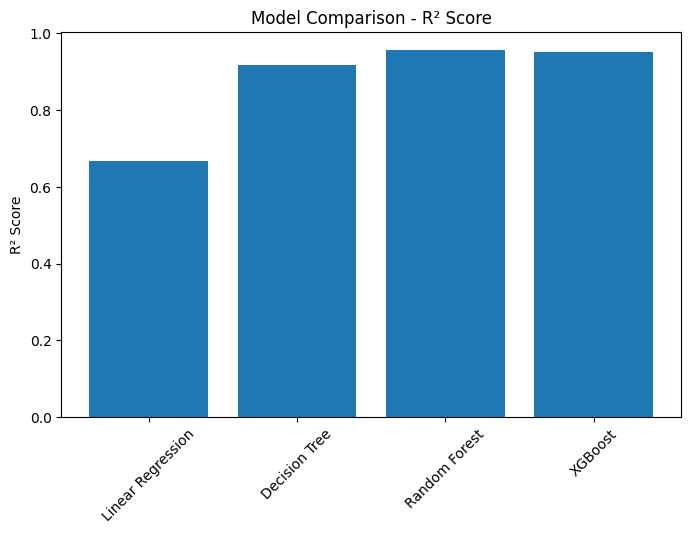

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["R2"])
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

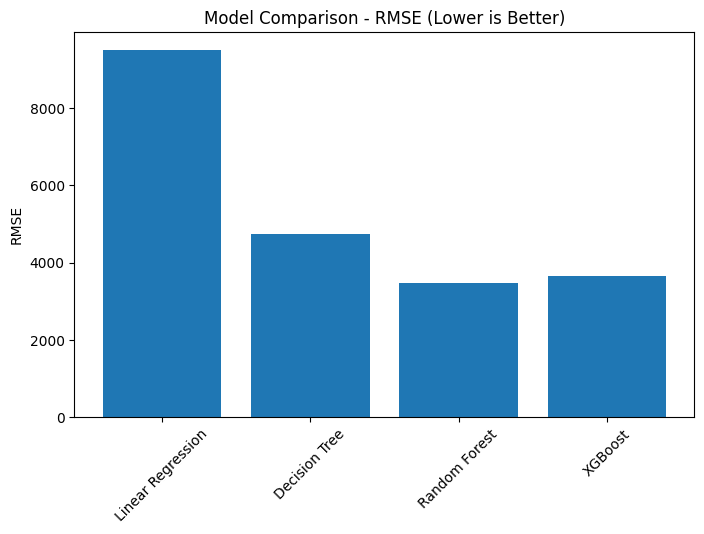

In [33]:
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["Test RMSE"])
plt.title("Model Comparison - RMSE (Lower is Better)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

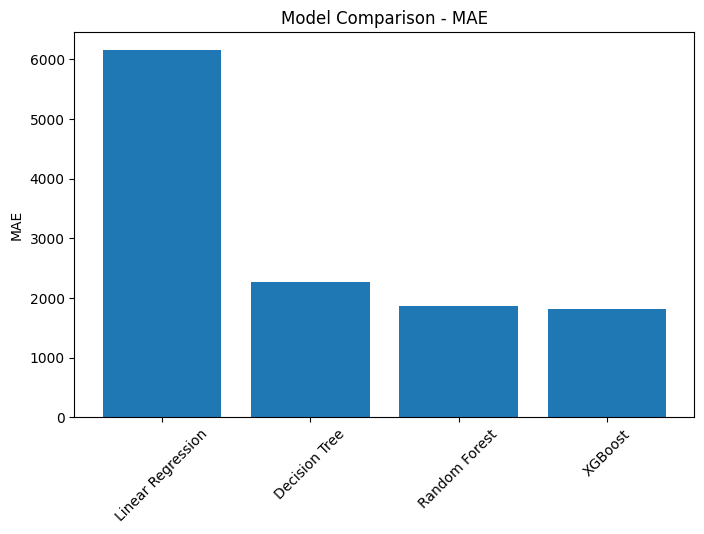

In [34]:
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["Test MAE"])
plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

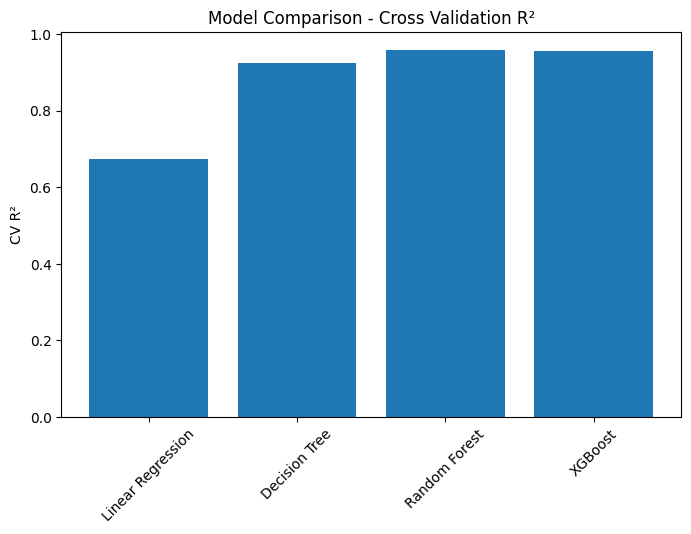

In [35]:
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["CV Mean R2"])
plt.title("Model Comparison - Cross Validation R²")
plt.ylabel("CV R²")
plt.xticks(rotation=45)
plt.show()

I Chose Best model is RandomForestRegressor

In [36]:
model =  RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [37]:
#import pickle

#pickle.dump(model, open('car_price_model.pkl', 'wb'))


In [38]:
print(x_train.columns)

Index(['Engine size', 'Year_of_manufacture', 'Mileage', 'Manufacturer_BMW',
       'Manufacturer_Ford', 'Manufacturer_Porsche', 'Manufacturer_Toyota',
       'Manufacturer_VW', 'Fuel_type_Diesel', 'Fuel_type_Hybrid',
       'Fuel_type_Petrol'],
      dtype='object')


In [39]:
import pandas as pd

new_car = pd.DataFrame([{
    "Engine size": 3.5,
    "Year_of_manufacture": 1999,
    "Mileage": 93695,

    "Manufacturer_BMW": 0,
    "Manufacturer_Ford": 0,
    "Manufacturer_Porsche": 1,
    "Manufacturer_Toyota": 0,
    "Manufacturer_VW": 0,

    "Fuel_type_Diesel": 0,
    "Fuel_type_Hybrid": 0,
    "Fuel_type_Petrol": 1
}])
new_car = new_car.reindex(columns=x_train.columns, fill_value=0)
predicted_price = model.predict(new_car)
print("Predicted Price:", predicted_price[0])

Predicted Price: 19232.452708950543
